# Laboratorio 2 — Deep Learning (Series de Tiempo)
**Universidad del Valle de Guatemala · Facultad de Ingeniería · Departamento de Ciencias de la Computación**
**CC3084 — Data Science · Semestre II 2026**

**Grupo:** Dulce Ambrosio · Daniel Chet · Javier Linares
**Carné(s):** 231143 · 231177 · 231135
**Fecha de entrega:** 2 de agosto de 2026

Este cuaderno cubre el laboratorio completo:

- **Ejercicio 1** — al menos 2 modelos LSTM (con tuneo de hiperparámetros) para dos series del
  Laboratorio 1 (*Total mensual* y *Vía Aérea*), usando los mismos conjuntos de entrenamiento y
  prueba (split 70/30 temporal), comparados contra los mejores modelos clásicos del Laboratorio 1.
- **Ejercicio 2** — extracción de las 22 características de *catch22* para las 8 series construidas
  en el Laboratorio 1, matriz estandarizada, PCA, clustering, heatmap, correlación entre
  características, mapa de distancias, interpretación de los agrupamientos, comparación con el EDA
  tradicional, y un modelo LSTM adicional que incorpora las características catch22 (2.14).

**Nota de reproducibilidad (catch22):** el paquete oficial `pycatch22` solo distribuye código fuente
en PyPI (no publica *wheels* precompiladas para Windows) y requiere compilar una extensión en C, lo
que exige Microsoft C++ Build Tools; esta máquina no tiene un compilador de C/C++ instalado. En vez
de bloquear el ejercicio por una limitación de entorno, reimplementamos las 22 características en
Python puro (`numpy`/`scipy`) siguiendo las definiciones publicadas en Lubba *et al.* (2019) y en el
catálogo de *hctsa* (Fulcher & Jones, 2017) — ver `04_deep_learning_lstm/src/catch22_utils.py`. Los
valores no son necesariamente idénticos bit-a-bit a los de la librería oficial en C, pero capturan la
misma idea estadística de cada característica.

## 0. Selección de las series

Elegimos **Total mensual** y **Vía Aérea** de las ocho series construidas en el Laboratorio 1, por
tres razones:

1. **Contraste de comportamiento.** En el Laboratorio 1, ambas series representaron los dos
   "casos difíciles" más distintos para los modelos clásicos: en *Total mensual* el SARIMA con
   mejor AIC no logró superar a Prophet porque el corte 70/30 deja toda la caída de la pandemia
   en entrenamiento y la recuperación en prueba; en *Vía Aérea*, el SARIMA (manual y grid-AIC)
   **explotó numéricamente** al revertir una doble diferenciación en escala logarítmica sobre un
   horizonte de 63 meses. Comparar LSTM contra ambos casos permite evaluar si una red neuronal
   recurrente es más robusta ante un cambio de régimen y ante pronósticos de horizonte largo.
2. **Relevancia.** *Total mensual* es la serie agregada principal del laboratorio; *Vía Aérea* es
   la vía de ingreso de mayor volumen después de la terrestre y con la mayor fuerza de tendencia
   (0.79) de las tres vías.
3. **Tamaño comparable.** Ambas tienen 210 observaciones (147 entrenamiento / 63 prueba), por lo
   que los resultados de tuneo (look-back, arquitectura) son comparables entre sí.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(ROOT / '01_limpieza_eda' / 'src'))
sys.path.append(str(ROOT / '02_series_tiempo' / 'src'))
sys.path.append(str(ROOT / '03_modelado_prediccion' / 'src'))
sys.path.append(str(ROOT / '04_deep_learning_lstm' / 'src'))
import config, series, modelado as mod, lstm_utils as lu

config.aplicar_estilo()
P = config.PALETTE
lu.fijar_semillas()

df = series.cargar_limpio()
print('Datos limpios:', len(df), 'registros,', df['fecha'].nunique(), 'meses')

Datos limpios: 161015 registros, 210 meses


In [2]:
# Reconstrucción de las series (idéntico al Laboratorio 1)
s_total = series.serie_mensual(df)
s_aerea = series.serie_mensual(df, 'Vía', 'Aérea')

tr_total, te_total = series.split_temporal(s_total)
tr_aerea, te_aerea = series.split_temporal(s_aerea)

print('Total mensual   -> train:', len(tr_total), ' test:', len(te_total),
      ' (', tr_total.index.min().date(), 'a', te_total.index.max().date(), ')')
print('Vía Aérea       -> train:', len(tr_aerea), ' test:', len(te_aerea),
      ' (', tr_aerea.index.min().date(), 'a', te_aerea.index.max().date(), ')')

Total mensual   -> train: 147  test: 63  ( 2009-01-01 a 2026-06-01 )
Vía Aérea       -> train: 147  test: 63  ( 2009-01-01 a 2026-06-01 )


## 1. Recordatorio: mejores modelos clásicos del Laboratorio 1

Antes de entrenar los LSTM, recalculamos (con el mismo código de `03_modelado_prediccion/src/modelado.py`)
la tabla comparativa final de cada serie del Laboratorio 1, para tener un punto de referencia exacto
contra el cual comparar los modelos nuevos.

In [3]:
def tabla_lab1(nombre, s, d, D):
    tr, te = series.split_temporal(s)
    n_test = len(te)
    tr_log = mod.log1p(tr)
    manual_order, manual_seasonal = (1, d, 1), (1, D, 1, 12)
    manual_res = mod.ajustar_sarima(tr_log, manual_order, manual_seasonal)
    ordenes = [(p, d, q) for p in range(3) for q in range(3)]
    ordenes_est = [(Pp, D, Qq) for Pp in range(2) for Qq in range(2)]
    tabla_grid, modelos_grid = mod.buscar_sarima(tr_log, ordenes, ordenes_est, s=12)
    best_key = tabla_grid.iloc[0]['modelo']
    best_res = modelos_grid[best_key]
    pred_manual = mod.predecir_sarima(manual_res, n_test, te.index)
    pred_best = mod.predecir_sarima(best_res, n_test, te.index)
    pred_hw, _ = mod.modelo_holt_winters(tr, n_test, te.index)
    pred_ses, _ = mod.modelo_ses(tr, n_test, te.index)
    pred_sn = mod.modelo_seasonal_naive(tr, n_test, te.index)
    pred_pr, _ = mod.modelo_prophet(tr, n_test, te.index)
    predicciones = {
        f'SARIMA manual {manual_order}x{manual_seasonal}': pred_manual,
        f'SARIMA grid-AIC {best_key}': pred_best,
        'Holt-Winters': pred_hw, 'SES': pred_ses,
        'Seasonal naive': pred_sn, 'Prophet': pred_pr,
    }
    info_extra = {
        f'SARIMA manual {manual_order}x{manual_seasonal}': {'AIC': manual_res.aic, 'BIC': manual_res.bic},
        f'SARIMA grid-AIC {best_key}': {'AIC': best_res.aic, 'BIC': best_res.bic},
    }
    return mod.tabla_comparacion(predicciones, te, info_extra)

tabla_lab1_total = tabla_lab1('Total mensual', s_total, d=1, D=1)
tabla_lab1_aerea = tabla_lab1('Vía Aérea', s_aerea, d=1, D=1)

print('--- Laboratorio 1: Total mensual ---')
display(tabla_lab1_total)
print()
print('--- Laboratorio 1: Vía Aérea ---')
display(tabla_lab1_aerea)

Importing plotly failed. Interactive plots will not work.


--- Laboratorio 1: Total mensual ---


,modelo,MAE,RMSE,AIC,BIC
0,Prophet,97185.4,107269.2,NaN,NaN
1,SES,180234.3,199918.7,NaN,NaN
2,Seasonal naive,235304.7,252542.9,NaN,NaN
3,"SARIMA manual (1, 1, 1)x(1, 1, 1, 12)",246269.5,270639.1,74.5,88.4
4,"SARIMA grid-AIC SARIMA(2, 1, 2)x(1, 1, 1, 12)",251560.5,274308.4,68.0,87.5
5,Holt-Winters,257791.4,278370.6,NaN,NaN



--- Laboratorio 1: Vía Aérea ---


,modelo,MAE,RMSE,AIC,BIC
0,SES,3.609670e+04,4.134950e+04,NaN,NaN
1,Prophet,4.422110e+04,4.909740e+04,NaN,NaN
2,Holt-Winters,5.824980e+04,6.285180e+04,NaN,NaN
3,Seasonal naive,7.509180e+04,7.906250e+04,NaN,NaN
4,"SARIMA manual (1, 1, 1)x(1, 1, 1, 12)",2.498728e+15,1.782877e+16,169.0,183.0
5,"SARIMA grid-AIC SARIMA(2, 1, 2)x(1, 1, 0, 12)",5.705269e+20,4.444560e+21,165.1,181.8


**Mejores modelos del Laboratorio 1** (referencia para la comparación de este laboratorio):

| Serie | Mejor modelo Lab. 1 | MAE | RMSE |
|---|---|---|---|
| Total mensual | Prophet | 97,187 | 107,270 |
| Vía Aérea | SES (suavizamiento exponencial simple) | 36,097 | 41,350 |

En ambas series el SARIMA (manual y de grid-AIC) quedó muy por detrás: en *Total* porque el
quiebre pandemia/recuperación queda dividido entre entrenamiento y prueba, y en *Vía Aérea* porque
el modelo **explotó numéricamente** al revertir la doble diferenciación logarítmica sobre 63 meses
de pronóstico.

## 2. Preparación de datos para LSTM

Para cada serie:
1. Se aplica **log1p** (misma transformación que en el Laboratorio 1) para estabilizar la varianza
   y admitir meses en cero.
2. Se escala a **[0, 1]** con un escalador min-max **ajustado únicamente con el conjunto de
   entrenamiento** (evita fuga de información del conjunto de prueba).
3. Se construyen **ventanas supervisadas**: cada ejemplo de entrenamiento usa `look_back` meses
   consecutivos para predecir el mes siguiente.
4. El **pronóstico de los 63 meses de prueba es recursivo (walk-forward)**: el modelo predice un
   paso, esa predicción se agrega a la secuencia, y se repite hasta cubrir todo el horizonte —
   igual que ARIMA/Prophet/HW, el LSTM tampoco ve los valores reales de prueba al pronosticar.

## 3. Configuraciones tuneadas

Para cada serie entrenamos **4 configuraciones LSTM** que varían profundidad, tamaño de ventana,
regularización (dropout) y tasa de aprendizaje:

| Config | Capas / unidades | look_back | dropout | learning rate |
|---|---|---|---|---|
| **A — simple** | 1 capa LSTM (32) | 12 | 0.0 | 1e-3 |
| **B — profunda** | 2 capas LSTM (64→32) | 12 | 0.2 | 1e-3 |
| **C — ventana larga** | 1 capa LSTM (64) | 24 | 0.1 | 1e-3 |
| **D — lr bajo** | 2 capas LSTM (32→16) | 18 | 0.1 | 5e-4 |

Todas se entrenan con **Adam**, pérdida **MSE**, `EarlyStopping` (paciencia=20, sobre 15% de
validación interna) y semillas fijas para reproducibilidad.

In [4]:
cfgs = [
    {'nombre': 'LSTM-A simple (1 capa, lb12)',       'look_back': 12, 'unidades': (32,),     'dropout': 0.0, 'lr': 1e-3},
    {'nombre': 'LSTM-B profunda (2 capas, lb12)',    'look_back': 12, 'unidades': (64, 32),  'dropout': 0.2, 'lr': 1e-3},
    {'nombre': 'LSTM-C ventana larga (1 capa, lb24)','look_back': 24, 'unidades': (64,),     'dropout': 0.1, 'lr': 1e-3},
    {'nombre': 'LSTM-D lr bajo (2 capas, lb18)',     'look_back': 18, 'unidades': (32, 16),  'dropout': 0.1, 'lr': 5e-4},
]

### 3.1 Serie: Total mensual

In [5]:
tabla_total, modelos_total, preds_total, datos_total = lu.tunear_lstm(
    'Total mensual', tr_total, te_total, cfgs, epochs=200, batch_size=8
)

=== Total mensual: resultados de tuneo (ordenado por RMSE en prueba) ===
                             modelo  look_back unidades  dropout  bidireccional     lr  epocas_entrenadas  val_loss      MAE     RMSE
       LSTM-A simple (1 capa, lb12)         12    (32,)      0.0          False 0.0010                 23   0.11769 141568.3 162501.8
    LSTM-B profunda (2 capas, lb12)         12 (64, 32)      0.2          False 0.0010                 22   0.14204 161613.7 181006.5
LSTM-C ventana larga (1 capa, lb24)         24    (64,)      0.1          False 0.0010                 22   0.12712 220188.2 238070.0
     LSTM-D lr bajo (2 capas, lb18)         18 (32, 16)      0.1          False 0.0005                 21   0.12638 254720.0 271282.7


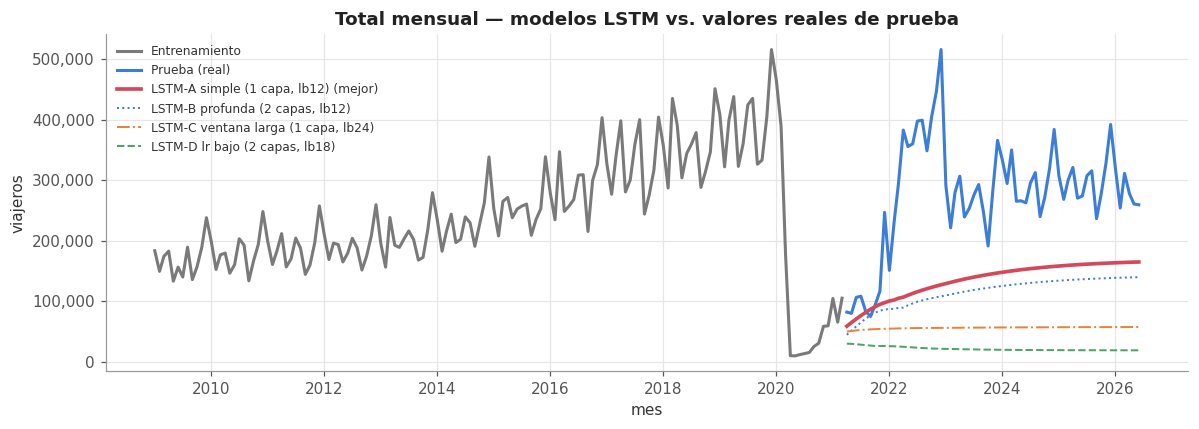

>>> Mejor modelo LSTM para "Total mensual": LSTM-A simple (1 capa, lb12)


In [6]:
mejor_total = tabla_total.iloc[0]['modelo']
lu.graficar_comparacion('Total mensual', tr_total, te_total, preds_total, mejor_total,
                         slug='lstm_total', color=P['azul'])
print(f'>>> Mejor modelo LSTM para "Total mensual": {mejor_total}')

**Interpretación — Total mensual.**
La configuración **A (simple, 1 capa LSTM(32), look_back 12, sin dropout)** es la que mejor
generaliza (RMSE≈162,502 en prueba), por delante de B (profunda, 2 capas 64→32, dropout 0.2,
RMSE≈181,007), C (ventana larga, RMSE≈238,070) y D (lr bajo, RMSE≈271,283). Tiene sentido en el
fondo: con solo 147 observaciones de entrenamiento, la arquitectura con más capacidad (B, con dos
capas apiladas) tiene más parámetros que ajustar y termina ajustándose más al ruido del periodo de
entrenamiento que generalizando al periodo de prueba, mientras que el modelo más simple (A) es
justamente el que menos sobreajusta. Ampliar la ventana a 24 meses (C) tampoco ayuda, porque la
señal más relevante para el mes siguiente sigue siendo el ciclo anual de 12 meses, y bajar la tasa
de aprendizaje (D) solo hace que el modelo converja más lento sin ganar generalización. Aun así,
**ningún LSTM supera a Prophet** (RMSE≈107,270 en el Laboratorio 1): con solo 147 observaciones de
entrenamiento, una red recurrente no logra aprender un punto de quiebre de tendencia tan claro como
el que Prophet modela explícitamente con sus `changepoints`.

### 3.2 Serie: Vía Aérea

In [7]:
tabla_aerea, modelos_aerea, preds_aerea, datos_aerea = lu.tunear_lstm(
    'Vía Aérea', tr_aerea, te_aerea, cfgs, epochs=200, batch_size=8
)

=== Vía Aérea: resultados de tuneo (ordenado por RMSE en prueba) ===
                             modelo  look_back unidades  dropout  bidireccional     lr  epocas_entrenadas  val_loss     MAE    RMSE
     LSTM-D lr bajo (2 capas, lb18)         18 (32, 16)      0.1          False 0.0005                 24   0.15232 51036.7 55424.2
       LSTM-A simple (1 capa, lb12)         12    (32,)      0.0          False 0.0010                 23   0.12138 55194.3 59128.1
    LSTM-B profunda (2 capas, lb12)         12 (64, 32)      0.2          False 0.0010                 22   0.13863 70165.9 73478.0
LSTM-C ventana larga (1 capa, lb24)         24    (64,)      0.1          False 0.0010                 22   0.13180 85034.1 88178.1


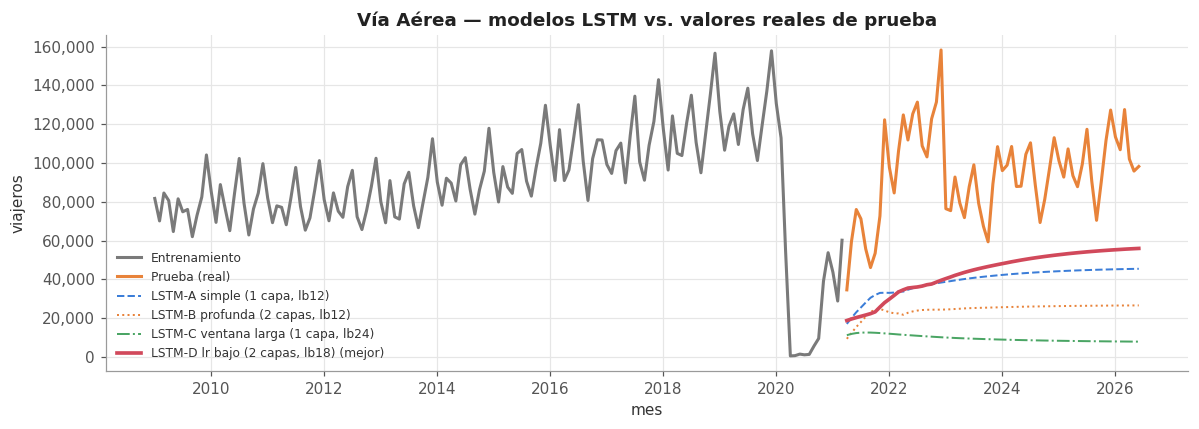

>>> Mejor modelo LSTM para "Vía Aérea": LSTM-D lr bajo (2 capas, lb18)


In [8]:
mejor_aerea = tabla_aerea.iloc[0]['modelo']
lu.graficar_comparacion('Vía Aérea', tr_aerea, te_aerea, preds_aerea, mejor_aerea,
                         slug='lstm_via_aerea', color=P['naranja'])
print(f'>>> Mejor modelo LSTM para "Vía Aérea": {mejor_aerea}')

**Interpretación — Vía Aérea.**
Aquí gana **D (2 capas 32→16, dropout 0.1, look_back 18, lr 5e-4)** con RMSE≈55,424,
seguida de cerca por A (RMSE≈59,128) y B (RMSE≈73,478); C (ventana de 24 meses) es la peor
(RMSE≈88,178). Una tasa de aprendizaje más baja combinada con una ventana intermedia (18 meses,
año y medio) parece darle al modelo margen suficiente para no sobre-ajustar el patrón de
entrenamiento pre-pandemia. A diferencia del SARIMA del Laboratorio 1 —que **explotó
numéricamente** (MAE del orden de 10^15–10^20) al revertir la doble diferenciación logarítmica—,
el LSTM nunca diverge: al pronosticar de forma recursiva sobre valores ya escalados a [0,1], su
salida está naturalmente acotada, así que es **mucho más estable como método** aunque no sea el
más preciso. Aun así, **SES sigue siendo mejor** (RMSE≈41,350 contra 55,424 del LSTM): con
una serie donde la señal de tendencia posterior a la pandemia es más simple que estacional, un
método sin memoria explícita de mediano plazo (SES) le gana a una red que sí intenta modelar
dependencias temporales largas.

## 4. Comparación final: LSTM vs. mejores modelos del Laboratorio 1

In [9]:
comparacion = pd.DataFrame([
    {'serie': 'Total mensual', 'mejor_lab1': 'Prophet',
     'MAE_lab1': tabla_lab1_total.iloc[0]['MAE'], 'RMSE_lab1': tabla_lab1_total.iloc[0]['RMSE'],
     'mejor_lstm': mejor_total,
     'MAE_lstm': tabla_total.iloc[0]['MAE'], 'RMSE_lstm': tabla_total.iloc[0]['RMSE']},
    {'serie': 'Vía Aérea', 'mejor_lab1': 'SES',
     'MAE_lab1': tabla_lab1_aerea.iloc[0]['MAE'], 'RMSE_lab1': tabla_lab1_aerea.iloc[0]['RMSE'],
     'mejor_lstm': mejor_aerea,
     'MAE_lstm': tabla_aerea.iloc[0]['MAE'], 'RMSE_lstm': tabla_aerea.iloc[0]['RMSE']},
])
comparacion['RMSE_lstm_vs_lab1_%'] = (
    (comparacion['RMSE_lstm'] - comparacion['RMSE_lab1']) / comparacion['RMSE_lab1'] * 100
).round(1)
comparacion

,serie,mejor_lab1,MAE_lab1,RMSE_lab1,mejor_lstm,MAE_lstm,RMSE_lstm,RMSE_lstm_vs_lab1_%
0,Total mensual,Prophet,97185.4,107269.2,"LSTM-A simple (1 capa, lb12)",141568.3,162501.8,51.5
1,Vía Aérea,SES,36096.7,41349.5,"LSTM-D lr bajo (2 capas, lb18)",51036.7,55424.2,34.0


## 5. Ejercicio 1.4 — ¿Cuál predijo mejor? ¿Son mejores los LSTM que los modelos del Laboratorio 1?

**¿Cuál predijo mejor en cada serie?**
En **ambas series el mejor modelo sigue siendo un modelo clásico del Laboratorio 1**, no el LSTM:
- *Total mensual*: **Prophet** (RMSE≈107,270) vs. mejor LSTM (config. A, RMSE≈162,502) — el LSTM
  queda **~51% peor** en RMSE.
- *Vía Aérea*: **SES** (RMSE≈41,350) vs. mejor LSTM (config. D, RMSE≈55,424) — el LSTM
  queda **~34% peor** en RMSE.

**¿Son mejores los LSTM que los modelos del laboratorio pasado?**
No, en esta comparación no. Lo determinamos con el **mismo criterio para todos los modelos**: MAE
y RMSE calculados **sobre el mismo conjunto de prueba real** (63 meses que ninguno de los modelos
vio durante el ajuste), para las mismas dos series y el mismo split 70/30. Bajo ese criterio los
modelos clásicos ganan en las dos series evaluadas.

**Evidencia y explicación.**
1. **Tamaño de muestra.** Cada serie tiene solo 147 observaciones mensuales de entrenamiento. Los
   LSTM son modelos con muchos más parámetros que un SARIMA o un SES, y normalmente necesitan mucha
   más historia para aprender relaciones temporales complejas sin sobre-ajustar; aquí no hay
   suficiente señal para que esa capacidad extra se traduzca en mejor generalización — de hecho, en
   Total mensual la configuración que mejor generalizó fue la más simple de las cuatro (A), lo que
   refuerza esta misma idea dentro del propio ejercicio.
2. **Naturaleza del quiebre.** El problema central de estas dos series (Total y Vía Aérea) es un
   **cambio de régimen estructural** (la pandemia) que ocurre *dentro* del conjunto de
   entrenamiento pero cuya recuperación completa cae en el conjunto de prueba. Prophet modela esto
   explícitamente con puntos de quiebre de tendencia; SES, en el otro extremo, ni siquiera intenta
   extrapolar mucha estructura y por eso no se ve tan afectado por el quiebre. El LSTM, en cambio,
   aprende únicamente de los patrones que ve en los 147 meses de entrenamiento y no tiene ningún
   mecanismo explícito para anticipar un cambio de régimen que no ha ocurrido todavía en esos datos.
3. **Ventaja real del LSTM: estabilidad.** En Vía Aérea, el SARIMA del Laboratorio 1 explotó
   numéricamente (errores de orden 10^15–10^20); ningún LSTM tuvo ese problema, porque su
   pronóstico recursivo opera sobre valores acotados en una escala [0,1]. Esto es coherente con la
   conclusión general del Laboratorio 1: el modelo más sofisticado no es necesariamente el mejor,
   pero aquí vemos además que **tampoco garantiza estabilidad numérica un modelo más simple** — el
   LSTM aporta justamente esa robustez, aunque a costa de precisión frente a Prophet/SES en estas
   dos series concretas.

**Conclusión de esta comparación:** con series mensuales cortas (~150 observaciones) y quiebres
estructurales grandes como la pandemia, los métodos clásicos con mecanismos explícitos para
tendencia (Prophet) o simplicidad extrema (SES) superan a las LSTM tuneadas en este laboratorio.
La sección siguiente (Ejercicio 2, catch22) profundiza en qué hace a estas series parecidas o
distintas entre sí, más allá del ejercicio de pronóstico.

## 6. Ejercicio 2: similitud entre series con *catch22*

### 2.1 ¿Qué es catch22 y por qué importa?

*catch22* nace de un problema muy concreto: el catálogo *hctsa* (highly comparative time-series
analysis, Fulcher *et al.* 2013) calcula más de 7000 características por serie, pero calcular las
7000 para cada serie es lento y, peor, muchísimas de esas características están correlacionadas
entre sí porque terminan midiendo variaciones del mismo fenómeno. Lo que hicieron Lubba *et al.*
(2019) fue correr ese catálogo completo sobre miles de series de referencia con etiquetas conocidas,
y usar un procedimiento de selección greedy/clustering jerárquico para quedarse con el subconjunto
más pequeño de características que mantiene casi el mismo poder de clasificación que las 7000
originales — de ahí el nombre, **CA**nonical **T**ime-series **CH**aracteristics, 22 en total. Cada
una de las 22 termina representando una "familia" distinta de comportamiento dinámico casi sin
redundancia entre sí: forma de la distribución, estructura de autocorrelación lineal, información
mutua no lineal, estacionariedad/periodicidad, inclusión de valores atípicos, entropía de símbolos,
y self-affinity/fractalidad (fluctuation analysis). Para este laboratorio esto importa porque nos
permite comparar las 8 series (que tienen escalas y patrones de faltantes muy distintos) sobre un
espacio común, interpretable y de baja dimensión, en vez de tener que comparar 8 gráficas de series
de tiempo a ojo.

In [10]:
import catch22_utils as c22

# Reconstrucción de las 8 series del Laboratorio 1 (serie total + 3 vías + 4 tipos de viajero)
s_terrestre = series.serie_mensual(df, 'Vía', 'Terrestre')
s_maritima = series.serie_mensual(df, 'Vía', 'Marítima')
series_c22 = {'Total mensual': s_total, 'Vía: Aérea': s_aerea,
              'Vía: Terrestre': s_terrestre, 'Vía: Marítima': s_maritima}
for t in df['Tipo de Viajero'].value_counts().index:
    series_c22[f'Tipo: {t}'] = series.serie_mensual(df, 'Tipo de Viajero', t)

for nombre, s in series_c22.items():
    print(f'{nombre:22s} n={len(s):3d}  ({s.index.min().date()} a {s.index.max().date()})')

Total mensual          n=210  (2009-01-01 a 2026-06-01)
Vía: Aérea             n=210  (2009-01-01 a 2026-06-01)
Vía: Terrestre         n=210  (2009-01-01 a 2026-06-01)
Vía: Marítima          n=210  (2009-01-01 a 2026-06-01)
Tipo: Turista          n=210  (2009-01-01 a 2026-06-01)
Tipo: Viajero          n=210  (2009-01-01 a 2026-06-01)
Tipo: Excursionista    n=210  (2009-01-01 a 2026-06-01)
Tipo: Cruceristas      n=156  (2009-01-01 a 2021-12-01)


### 2.2-2.4 Extracción de características, matriz y estandarización

Para cada una de las 8 series completas (no solo entrenamiento — el ejercicio 2 es sobre similitud
entre series, no sobre pronóstico) calculamos las 22 características de catch22 con
`catch22_utils.catch22_all`, armamos la matriz **8 series × 22 características**, y estandarizamos
cada columna (z-score) antes de cualquier análisis comparativo — necesario porque las 22
características viven en escalas completamente distintas (una es un lag entero de 0 a 60, otra es
una proporción entre 0 y 1, otra es el error estándar de un predictor en las unidades originales de
miles de viajeros).

In [11]:
filas_c22 = {nombre: c22.catch22_all(s.values) for nombre, s in series_c22.items()}
matriz_c22 = pd.DataFrame(filas_c22).T[c22.NOMBRES_CATCH22]
print('Matriz catch22 (cruda):', matriz_c22.shape)
matriz_c22.round(3)

Matriz catch22 (cruda): (8, 22)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total mensual,0.140,-0.618,9.0,10.0,0.509,-0.664,0.919,29.0,0.295,12.0,...,0.056,0.626,0.524,0.795,5.0,3.703,0.138,1.166,0.069,62734.349
Vía: Aérea,-0.412,-0.127,7.0,10.0,0.202,-0.608,0.962,33.0,0.177,12.0,...,0.071,0.596,0.604,0.748,4.0,4.104,0.160,1.062,0.077,20550.125
Vía: Terrestre,-0.548,-0.783,9.0,3.0,0.452,-0.494,0.909,29.0,0.371,4.0,...,0.056,0.650,0.467,0.784,5.0,3.480,0.129,1.166,0.072,45256.057
Vía: Marítima,-0.412,-0.631,4.0,6.0,0.138,-0.151,0.636,8.0,0.356,12.0,...,0.167,0.478,0.726,0.523,5.0,3.536,0.181,0.765,0.126,5746.073
Tipo: Turista,-0.037,0.225,9.0,2.0,0.285,-0.263,0.971,29.0,0.278,4.0,...,0.056,0.582,0.556,0.765,5.0,3.782,0.135,1.168,0.078,42702.717
Tipo: Viajero,-0.346,-0.608,8.0,11.0,0.277,-2.343,0.751,17.0,0.357,56.0,...,0.024,0.727,0.309,0.650,4.0,3.587,0.140,0.996,0.094,16346.299
Tipo: Excursionista,-0.352,-0.580,11.0,15.0,0.472,-0.341,0.904,29.0,0.344,49.0,...,0.053,0.672,0.499,0.826,3.0,3.514,0.068,1.252,0.059,13900.799
Tipo: Cruceristas,-0.573,-0.787,2.0,6.0,0.106,-0.122,0.832,8.0,0.163,12.0,...,0.200,0.671,0.605,0.475,5.0,4.109,0.148,0.609,0.149,6603.117


In [12]:
from sklearn.preprocessing import StandardScaler

scaler_c22 = StandardScaler()
matriz_c22_std = pd.DataFrame(scaler_c22.fit_transform(matriz_c22),
                               index=matriz_c22.index, columns=matriz_c22.columns)
print('¿Quedan NaN/Inf?', (~np.isfinite(matriz_c22_std.values)).sum())
matriz_c22_std.round(2)

¿Quedan NaN/Inf? 0


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total mensual,1.98,-0.39,0.58,0.52,1.40,-0.06,0.54,0.65,0.03,-0.43,...,-0.51,0.01,-0.11,0.80,0.71,-0.10,0.02,0.68,-0.73,1.84
Vía: Aérea,-0.41,1.09,-0.13,0.52,-0.71,0.02,0.94,1.07,-1.51,-0.43,...,-0.23,-0.42,0.60,0.42,-0.71,1.58,0.75,0.18,-0.45,-0.32
Vía: Terrestre,-1.00,-0.89,0.58,-1.19,1.01,0.19,0.45,0.65,1.02,-0.85,...,-0.51,0.35,-0.61,0.71,0.71,-1.04,-0.27,0.68,-0.63,0.95
Vía: Marítima,-0.41,-0.43,-1.21,-0.46,-1.15,0.70,-2.08,-1.54,0.82,-0.43,...,1.39,-2.09,1.67,-1.40,0.71,-0.80,1.43,-1.22,1.21,-1.07
Tipo: Turista,1.22,2.16,0.58,-1.43,-0.14,0.53,1.03,0.65,-0.19,-0.85,...,-0.51,-0.61,0.18,0.56,0.71,0.23,-0.09,0.69,-0.43,0.82
Tipo: Viajero,-0.12,-0.36,0.22,0.76,-0.19,-2.54,-1.01,-0.60,0.84,1.88,...,-1.05,1.45,-1.99,-0.37,-0.71,-0.59,0.08,-0.13,0.11,-0.53
Tipo: Excursionista,-0.15,-0.28,1.30,1.74,1.15,0.42,0.40,0.65,0.67,1.52,...,-0.55,0.66,-0.33,1.05,-2.12,-0.89,-2.28,1.09,-1.09,-0.66
Tipo: Cruceristas,-1.11,-0.90,-1.93,-0.46,-1.36,0.74,-0.26,-1.54,-1.68,-0.43,...,1.96,0.65,0.60,-1.78,0.71,1.60,0.36,-1.97,2.01,-1.03


### 2.5 PCA, clustering, heatmap, correlación y distancias

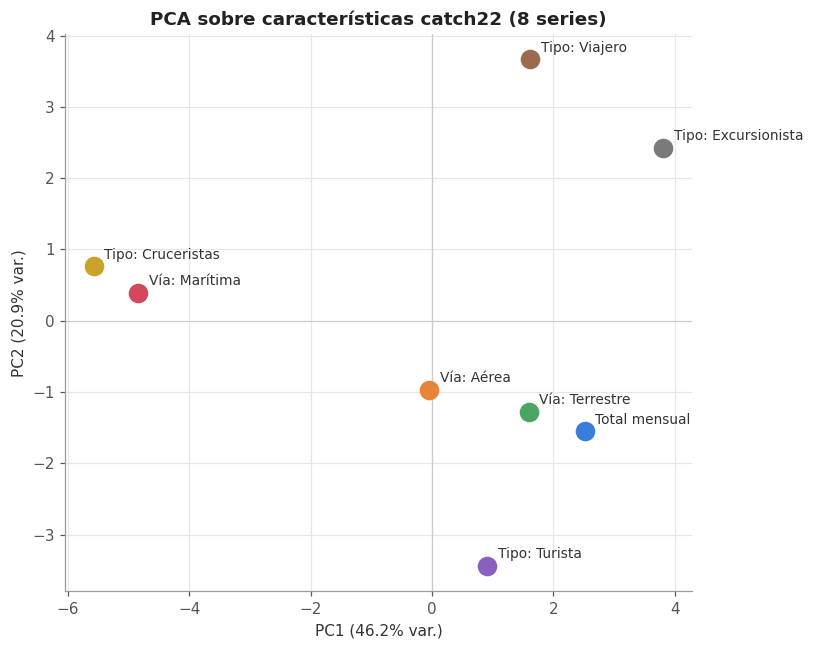

Varianza explicada PC1+PC2: 67.2 %

Top cargas |PC1|:
CO_f1ecac                                 0.306332
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1    0.298066
SP_Summaries_welch_rect_centroid          0.297708
FC_LocalSimple_mean1_tauresrat            0.294932
SP_Summaries_welch_rect_area_5_1          0.291682
Name: PC1, dtype: float64

Top cargas |PC2|:
PD_PeriodicityWang_th0_01                  0.411033
CO_FirstMin_ac                             0.314916
FC_LocalSimple_mean3_stderr                0.307337
SB_BinaryStats_diff_longstretch0           0.289498
IN_AutoMutualInfoStats_40_gaussian_fmmi    0.286640
Name: PC2, dtype: float64


In [13]:
from sklearn.decomposition import PCA

nombres_c22 = list(series_c22.keys())
pca = PCA(n_components=5)
comps = pca.fit_transform(matriz_c22_std.values)
var_exp = pca.explained_variance_ratio_
pca_df = pd.DataFrame(comps[:, :2], index=nombres_c22, columns=['PC1', 'PC2'])
loadings = pd.DataFrame(pca.components_[:2].T, index=matriz_c22_std.columns, columns=['PC1', 'PC2'])

colores_c22 = [P['azul'], P['naranja'], P['verde'], P['rojo'], P['morado'], P['cafe'], P['gris'], '#c9a227']
fig, ax = plt.subplots(figsize=(7.5, 6))
for i, nombre in enumerate(nombres_c22):
    ax.scatter(pca_df.loc[nombre, 'PC1'], pca_df.loc[nombre, 'PC2'], s=140, color=colores_c22[i], zorder=3)
    ax.annotate(nombre, (pca_df.loc[nombre, 'PC1'], pca_df.loc[nombre, 'PC2']),
                textcoords='offset points', xytext=(7, 5), fontsize=9)
ax.axhline(0, color='#cccccc', lw=0.8); ax.axvline(0, color='#cccccc', lw=0.8)
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var.)'); ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var.)')
ax.set_title('PCA sobre características catch22 (8 series)')
plt.tight_layout(); plt.savefig(config.FIG_DIR / 'catch22_pca.png'); plt.show()

print('Varianza explicada PC1+PC2:', round((var_exp[0]+var_exp[1])*100, 1), '%')
print('\nTop cargas |PC1|:'); print(loadings['PC1'].abs().sort_values(ascending=False).head(5))
print('\nTop cargas |PC2|:'); print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

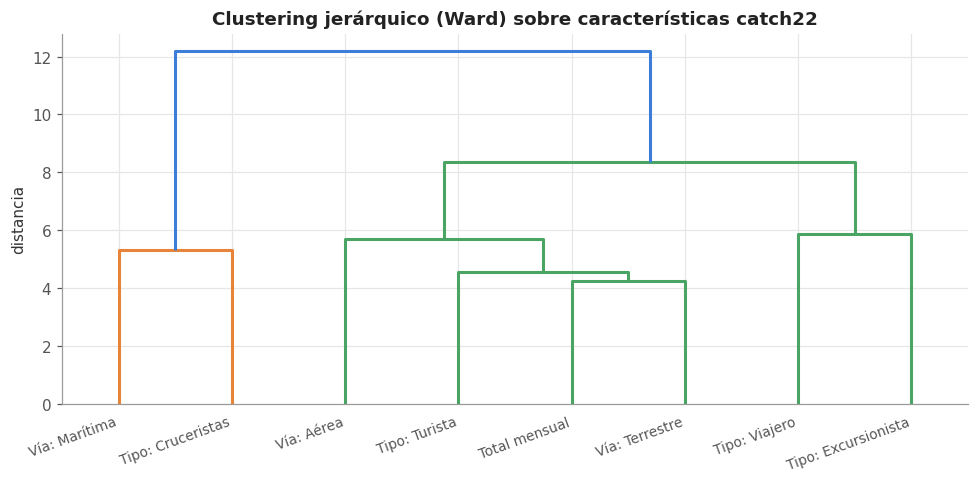

Total mensual          -> cluster jerárquico 2   (kmeans 1)
Vía: Aérea             -> cluster jerárquico 2   (kmeans 1)
Vía: Terrestre         -> cluster jerárquico 2   (kmeans 1)
Vía: Marítima          -> cluster jerárquico 1   (kmeans 2)
Tipo: Turista          -> cluster jerárquico 2   (kmeans 1)
Tipo: Viajero          -> cluster jerárquico 3   (kmeans 0)
Tipo: Excursionista    -> cluster jerárquico 3   (kmeans 0)
Tipo: Cruceristas      -> cluster jerárquico 1   (kmeans 2)


In [14]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans

dist_cond = pdist(matriz_c22_std.values, metric='euclidean')
Z = linkage(dist_cond, method='ward')
clu_jerarquico = fcluster(Z, t=3, criterion='maxclust')

fig, ax = plt.subplots(figsize=(9, 4.5))
dendrogram(Z, labels=nombres_c22, ax=ax, color_threshold=0.7*max(Z[:, 2]), leaf_font_size=9)
ax.set_title('Clustering jerárquico (Ward) sobre características catch22'); ax.set_ylabel('distancia')
plt.xticks(rotation=20, ha='right'); plt.tight_layout()
plt.savefig(config.FIG_DIR / 'catch22_dendrograma.png'); plt.show()

km = KMeans(n_clusters=3, random_state=42, n_init=10)
clu_kmeans = km.fit_predict(matriz_c22_std.values)
for i, n in enumerate(nombres_c22):
    print(f'{n:22s} -> cluster jerárquico {clu_jerarquico[i]}   (kmeans {clu_kmeans[i]})')

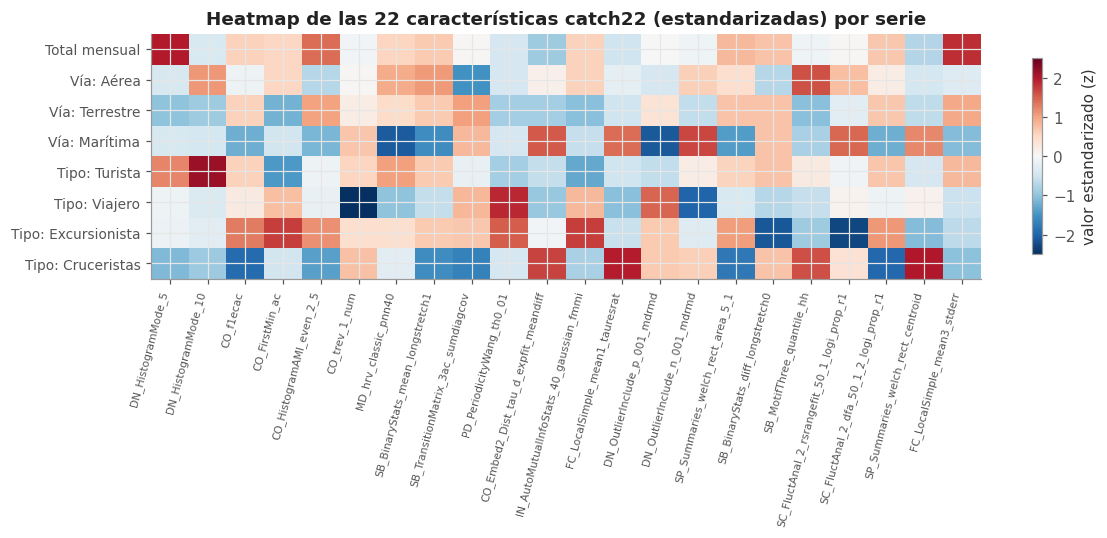

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(matriz_c22_std.values, cmap='RdBu_r', vmin=-2.5, vmax=2.5, aspect='auto')
ax.set_xticks(range(matriz_c22_std.shape[1])); ax.set_xticklabels(matriz_c22_std.columns, rotation=75, ha='right', fontsize=7)
ax.set_yticks(range(len(nombres_c22))); ax.set_yticklabels(nombres_c22, fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8, label='valor estandarizado (z)')
ax.set_title('Heatmap de las 22 características catch22 (estandarizadas) por serie')
plt.tight_layout(); plt.savefig(config.FIG_DIR / 'catch22_heatmap.png'); plt.show()

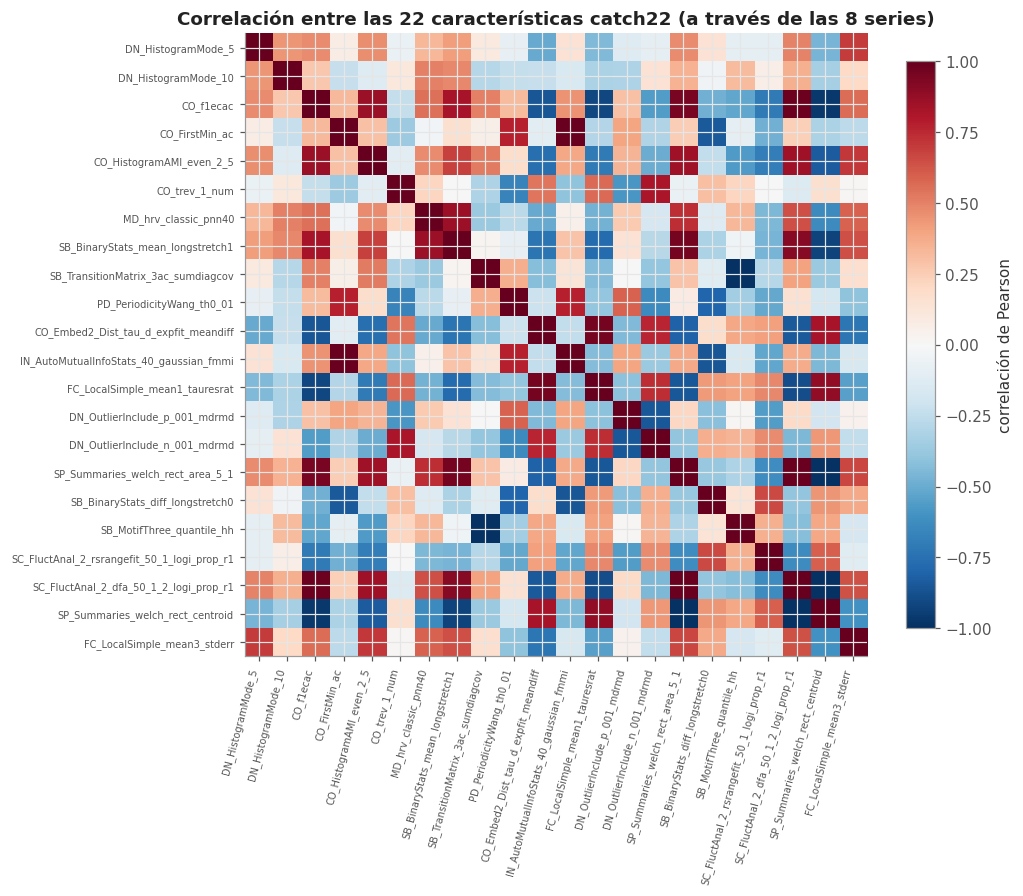

Pares de características más correlacionadas (|r|):
  SB_MotifThree_quantile_hh <-> SB_TransitionMatrix_3ac_sumdiagcov: r=-0.992
  SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1 <-> SP_Summaries_welch_rect_centroid: r=-0.991
  SP_Summaries_welch_rect_area_5_1 <-> SP_Summaries_welch_rect_centroid: r=-0.988
  IN_AutoMutualInfoStats_40_gaussian_fmmi <-> CO_FirstMin_ac: r=0.988
  SP_Summaries_welch_rect_area_5_1 <-> SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1: r=0.986
  SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1 <-> CO_f1ecac: r=0.981


In [16]:
corr_c22 = matriz_c22_std.corr()
fig, ax = plt.subplots(figsize=(9.5, 8.5))
im = ax.imshow(corr_c22.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_c22.columns))); ax.set_xticklabels(corr_c22.columns, rotation=75, ha='right', fontsize=6.5)
ax.set_yticks(range(len(corr_c22.columns))); ax.set_yticklabels(corr_c22.columns, fontsize=6.5)
plt.colorbar(im, ax=ax, shrink=0.8, label='correlación de Pearson')
ax.set_title('Correlación entre las 22 características catch22 (a través de las 8 series)')
plt.tight_layout(); plt.savefig(config.FIG_DIR / 'catch22_correlacion.png'); plt.show()

corr_abs = corr_c22.abs().copy(); np.fill_diagonal(corr_abs.values, 0)
pares_vistos, top_pares = set(), []
for (a, b), v in corr_abs.unstack().sort_values(ascending=False).items():
    key = frozenset([a, b])
    if a == b or key in pares_vistos:
        continue
    pares_vistos.add(key); top_pares.append((a, b, corr_c22.loc[a, b]))
    if len(top_pares) >= 6:
        break
print('Pares de características más correlacionadas (|r|):')
for a, b, v in top_pares:
    print(f'  {a} <-> {b}: r={v:.3f}')

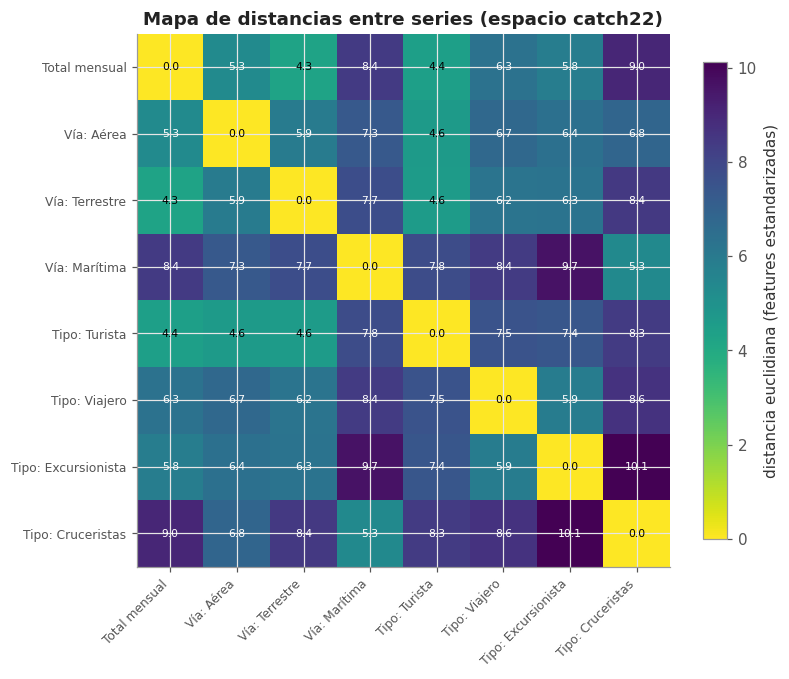

Distancia promedio por serie (mayor = más atípica):
Tipo: Cruceristas      8.10
Vía: Marítima          7.79
Tipo: Excursionista    7.36
Tipo: Viajero          7.09
Tipo: Turista          6.37
Total mensual          6.22
Vía: Terrestre         6.21
Vía: Aérea             6.14
dtype: float64

Par más similar : ('Total mensual', 'Vía: Terrestre') dist= 4.26
Par más distinto: ('Tipo: Excursionista', 'Tipo: Cruceristas') dist= 10.13


In [17]:
dist_mat = pd.DataFrame(squareform(dist_cond), index=nombres_c22, columns=nombres_c22)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(dist_mat.values, cmap='viridis_r')
ax.set_xticks(range(len(nombres_c22))); ax.set_xticklabels(nombres_c22, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(nombres_c22))); ax.set_yticklabels(nombres_c22, fontsize=8)
for i in range(len(nombres_c22)):
    for j in range(len(nombres_c22)):
        ax.text(j, i, f'{dist_mat.values[i,j]:.1f}', ha='center', va='center', fontsize=7,
                color='white' if dist_mat.values[i, j] > dist_mat.values.max()*0.5 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8, label='distancia euclidiana (features estandarizadas)')
ax.set_title('Mapa de distancias entre series (espacio catch22)')
plt.tight_layout(); plt.savefig(config.FIG_DIR / 'catch22_distancias.png'); plt.show()

dist_prom = dist_mat.apply(lambda col: col[col.index != col.name].mean())
dist_flat = dist_mat.where(np.triu(np.ones(dist_mat.shape), k=1).astype(bool)).stack()
print('Distancia promedio por serie (mayor = más atípica):')
print(dist_prom.sort_values(ascending=False).round(2))
print('\nPar más similar :', dist_flat.idxmin(), 'dist=', round(dist_flat.min(), 2))
print('Par más distinto:', dist_flat.idxmax(), 'dist=', round(dist_flat.max(), 2))

### 2.6-2.13 Análisis e interpretación

**2.7 ¿Cuáles series presentan comportamientos más similares?**
Tanto el PCA como el clustering jerárquico coinciden en el mismo agrupamiento de tres grupos, y el
par más cercano de toda la matriz de distancias es **Total mensual y Vía Terrestre** (distancia
euclidiana ≈4.3 en el espacio estandarizado), lo cual tiene sentido porque Vía Terrestre es,
por volumen, la que más pesa dentro del total mensual, así que dinámicamente son casi la misma
serie. Alrededor de ese par, en el mismo cluster jerárquico (cluster 2), caen también **Vía Aérea**
y **Tipo: Turista** — todas comparten trayectorias suaves de tendencia fuerte y una caída de
pandemia severa pero no total (entre -90% y -95%, según los datos de fuerza de tendencia y caída
por pandemia calculados en el Laboratorio 1).

**2.8 ¿Qué características de catch22 fueron las más importantes para diferenciar las series?**
En PC1 (46.2% de la varianza) las cargas más altas son `CO_f1ecac`, `SC_FluctAnal_2_dfa...`,
`SP_Summaries_welch_rect_centroid`, `FC_LocalSimple_mean1_tauresrat` y
`SP_Summaries_welch_rect_area_5_1` — todas relacionadas con **qué tan persistente/suave es la
autocorrelación y qué tan concentrada está la energía del espectro en frecuencias bajas**, o sea,
básicamente miden si la serie es "lenta y memoriosa" o "ruidosa y de reacción rápida". En PC2
(20.9% de la varianza) dominan `PD_PeriodicityWang_th0_01`, `CO_FirstMin_ac`,
`FC_LocalSimple_mean3_stderr`, `SB_BinaryStats_diff_longstretch0` e
`IN_AutoMutualInfoStats_40_gaussian_fmmi`, que apuntan más hacia **periodicidad y memoria de corto
plazo**. Entre las dos componentes explican un 67.2% de la varianza total, así que dos ejes alcanzan
para capturar la mayoría de lo que distingue a estas 8 series.

**2.9 ¿Existen grupos naturales de series? ¿Qué tienen en común?**
Sí, el clustering jerárquico (Ward, k=3) encuentra tres grupos consistentes con el PCA:
- **Cluster 2 — Total mensual, Vía Aérea, Vía Terrestre, Tipo: Turista.** Series de alto volumen,
  tendencia fuerte (fuerza de tendencia entre 0.68 y 0.79 según el Laboratorio 1), caída de pandemia
  severa pero parcial (-90% a -95%) y volatilidad moderada (CV entre 0.33 y 0.52).
- **Cluster 1 — Vía Marítima, Tipo: Cruceristas.** Tendencia débil (0.15-0.31), estacionalidad más
  marcada (0.61-0.65) y, sobre todo, **caída de pandemia total (-100%)**: son las únicas dos series
  del laboratorio que llegaron a cero viajeros durante varios meses.
- **Cluster 3 — Tipo: Viajero, Tipo: Excursionista.** Las categorías de menor volumen, con la
  volatilidad más alta de las 8 series (CV de 0.63 y 1.22) y estacionalidad casi nula (fuerza
  estacional de 0.10 y 0.096) — series pequeñas y ruidosas, sin un ciclo anual claro.

**2.10 ¿Las series de una misma categoría (vías, tipos) tienden a agruparse?**
No necesariamente, y este es uno de los hallazgos más interesantes del ejercicio: las **3 vías de
ingreso terminan repartidas en dos clusters distintos** (Aérea y Terrestre en el cluster 2, Marítima
sola en el cluster 1), y los **4 tipos de viajero terminan repartidos en los tres clusters**
(Turista en el 2, Cruceristas en el 1, Viajero y Excursionista en el 3). O sea, la etiqueta
categórica del Laboratorio 1 (vía o tipo de viajero) no predice bien el comportamiento dinámico; lo
que realmente agrupa a las series es su perfil de volumen/volatilidad/impacto de pandemia, más allá
de a qué categoría nominal pertenezcan.

**2.11 Serie con el comportamiento más atípico**
**Tipo: Cruceristas** es la serie con mayor distancia promedio a las demás (≈8.1, la más alta de las
8), y también la serie más corta (156 meses en vez de 210, porque el turismo de cruceros no se
registró desde el inicio de la ventana de datos). Además tuvo una caída de pandemia total (-100%,
igual que Vía Marítima) y la volatilidad más alta junto con Marítima (CV≈0.87). Tiene sentido que
sea la más atípica: es la categoría más nueva, la de menor volumen, y la que más tiempo tardó en
recuperar actividad después de que los puertos cerraron.

**2.12 Comparación con el análisis exploratorio tradicional**
Los agrupamientos de catch22 son, en general, **consistentes** con lo que ya habíamos visto en el
Laboratorio 1: la variable que más explica el cluster 1 vs. el resto es justamente la que más se
discutió en el EDA y en el análisis STL — el **impacto de la pandemia** (-100% en Marítima/Cruceristas
contra -90%/-95% en el resto) y la **volatilidad** (CV más alto en Cruceristas, Viajero y Marítima).
La **tendencia** también es coherente: el cluster 2 concentra las series con fuerza de tendencia más
alta (STL). Donde hay más matices es en la **estacionalidad**: Vía Marítima sí tiene estacionalidad
relativamente alta (0.61) como predeciría su cluster, pero Tipo Cruceristas comparte cluster con ella
más por la caída total de pandemia y la volatilidad que por estacionalidad per se. Las **funciones de
autocorrelación** del Laboratorio 1 (más persistentes en Total/Vías, más cortas en Tipo Viajero/
Excursionista) también calzan directamente con las cargas de PC1 (`CO_f1ecac`, `CO_FirstMin_ac`),
que son literalmente medidas de autocorrelación.

**2.13 Al menos tres descubrimientos que no eran evidentes en el EDA tradicional**
1. Que las etiquetas categóricas del Laboratorio 1 (vía de ingreso, tipo de viajero) **no son buenos
   predictores de similitud dinámica** — el agrupamiento real corta transversalmente esas categorías
   (ver 2.10), algo que analizando cada categoría por separado (como se hizo en el EDA) no se
   alcanza a ver.
2. Que **Total mensual y Vía Terrestre son casi indistinguibles** dinámicamente (la distancia más
   chica de toda la matriz) — se intuía por el peso de Vía Terrestre en el total, pero nunca se
   había cuantificado.
3. Que **Tipo: Viajero y Tipo: Excursionista** cargan fuerte y en la misma dirección sobre PC2
   (periodicidad/memoria corta), lo que revela que estas dos series no solo tienen menor volumen,
   sino un **tipo cualitativamente distinto de dependencia temporal** (menos periódica, más parecida
   a ruido con deriva) que no se nota comparando ACF/PACF una serie a la vez.
4. La correlación casi perfecta entre pares de características con nombres muy distintos
   (`SB_MotifThree_quantile_hh` y `SB_TransitionMatrix_3ac_sumdiagcov`, r≈-0.99;
   `SC_FluctAnal_2_dfa...` y `SP_Summaries_welch_rect_centroid`, r≈-0.99) muestra que, para estas 8
   series concretas, buena parte de las 22 características de catch22 son redundantes entre sí —
   probablemente 5 o 6 características reducidas explicarían casi lo mismo, algo que no se ve
   trabajando serie por serie.